In [70]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from scipy.integrate import odeint

In [71]:
def test_int(X, t, betat, gamma, mu):
    S = -betat(t)*X[0]*X[1]-mu*X[0]+mu
    I = betat(t)*X[0]*X[1]-(mu+gamma)*X[1]
    R = gamma*X[1]-mu*X[2]

    A = np.matrix([[-betat(t)*X[1]-mu,-betat(t)*X[0]], 
                   [betat(t)*X[1],-(gamma+mu)+betat(t)*X[0]],
                   ])
    B = np.matrix([[betat(t)*X[0]*X[1]+mu*X[0]+mu,-betat(t)*X[0]*X[1]],
                   [-betat(t)*X[0]*X[1],betat(t)*X[0]*X[1]+(gamma+mu)*X[1]],
                   ])

    Θ = np.matrix([[X[3],X[4]],
                   [X[4],X[5]],
                   ])

    K = A*Θ +Θ*A.transpose()+B
    return [S, I, R, K[0,0], K[0,1], K[1,1]]

def jac(X, t, betat, gamma, mu):
    A = np.matrix([[-betat(t)*X[1]-mu,-betat(t)*X[0]], 
                   [betat(t)*X[1],-(gamma+mu)+betat(t)*X[0]],
                   ])
    return A

def Q_calc(X, t, betat, gamma, mu):
    B = np.matrix([[betat(t)*X[0]*X[1]+mu*X[0]+mu,-betat(t)*X[0]*X[1]],
                   [-betat(t)*X[0]*X[1],betat(t)*X[0]*X[1]+(gamma+mu)*X[1]],
                   ])
    return B

def test_int_multin(X, t, betat, gamma, mu):
    S = -betat(t)*X[0]*X[1]-mu*X[0]+mu
    I = betat(t)*X[0]*X[1]-(mu+gamma)*X[1]
    R = gamma*X[1]-mu*X[2]

    A = np.matrix([[-betat(t)*X[1]-mu,-betat(t)*X[0],0], 
                   [betat(t)*X[1],-(gamma+mu)+betat(t)*X[0],0],
                   [0, gamma, -mu]])
    B = np.matrix([[betat(t)*X[0]*X[1]+mu*X[0]+mu,-betat(t)*X[0]*X[1],0],
                   [-betat(t)*X[0]*X[1],betat(t)*X[0]*X[1]+(gamma+mu)*X[1],-gamma*X[1]],
                   [0,-gamma*X[1],gamma*X[1]+mu*X[2]]])

    Θ = np.matrix([[X[3],X[4],X[5]],
                   [X[4],X[6],X[7]],
                   [X[5],X[7],X[8]]])

    K = A*Θ +Θ*A.transpose()+B
    return [S, I, R, K[0,0], K[0,1], K[0,2], K[1,1], K[1,2], K[2,2]]

In [72]:
file_list = glob.glob('Sim_results/low/1000/I*.npy')
for i, file in enumerate(file_list):
    low_1000 = np.load(file) if i == 0 else np.vstack((low_1000,np.load(file)))
low_1000 = low_1000 / 1000
df_1000 = pd.DataFrame(low_1000).T
stoch_cst = df_1000.sub(df_1000.mean(axis = 1), axis = 'rows')
df_1000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/low/10000/I*.npy')
for i, file in enumerate(file_list):
    low_10000 = np.load(file) if i == 0 else np.vstack((low_10000,np.load(file)))
low_10000 = low_10000 / 10000
df_10000 = pd.DataFrame(low_10000).T
stoch_cst = df_10000.sub(df_10000.mean(axis = 1), axis = 'rows')
df_10000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/low/100000/I*.npy')
for i, file in enumerate(file_list):
    low_100000 = np.load(file) if i == 0 else np.vstack((low_100000,np.load(file)))
low_100000 = low_100000 / 100000
df_100000 = pd.DataFrame(low_100000).T
stoch_cst = df_100000.sub(df_100000.mean(axis = 1), axis = 'rows')
df_100000_var = stoch_cst.var(axis=1).values

In [73]:
N = 1e5  # Total population
gamma = 1/14  # Recovery rate (1/gamma is the infectious period)
mu = 0.00003424657  # Birth and death rate
beta0 = 0.06
betat = lambda x: beta0
ts = np.linspace(0,250,2501)
X0 = [0.9, 0.1, 0, 0, 0, 0]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
S, I, R = sol[:,0], sol[:,1], sol[:,2]
Sigma11, Sigma12, Sigma22 = sol[:,3], sol[:,4], sol[:,5]
days = np.arange(0,251)

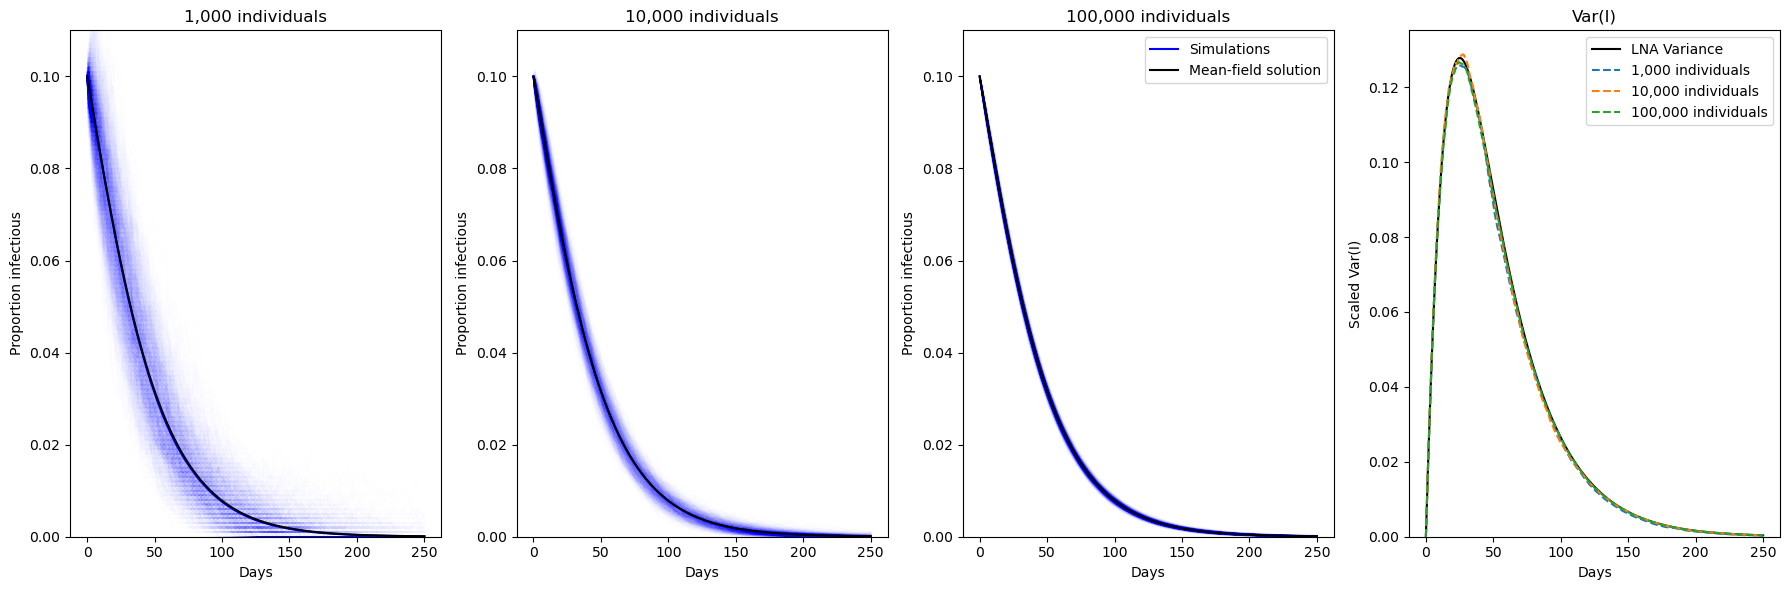

In [74]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_10000.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, df_1000_var*1000, linestyle = '--', label = '1,000 individuals')
axs[3].plot(days, df_10000_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_100000_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.11),(0,0.11),(0,0.11),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [75]:
file_list = glob.glob('Sim_results/lowrand/1000/I*.npy')
for i, file in enumerate(file_list):
    low_1000 = np.load(file) if i == 0 else np.vstack((low_1000,np.load(file)))
low_1000 = low_1000 / 1000
df_1000 = pd.DataFrame(low_1000).T
stoch_cst = df_1000.sub(df_1000.mean(axis = 1), axis = 'rows')
df_1000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/lowrand/10000/I*.npy')
for i, file in enumerate(file_list):
    low_10000 = np.load(file) if i == 0 else np.vstack((low_10000,np.load(file)))
low_10000 = low_10000 / 10000
df_10000 = pd.DataFrame(low_10000).T
stoch_cst = df_10000.sub(df_10000.mean(axis = 1), axis = 'rows')
df_10000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/lowrand/100000/I*.npy')
for i, file in enumerate(file_list):
    low_100000 = np.load(file) if i == 0 else np.vstack((low_100000,np.load(file)))
low_100000 = low_100000 / 100000
df_100000 = pd.DataFrame(low_100000).T
stoch_cst = df_100000.sub(df_100000.mean(axis = 1), axis = 'rows')
df_100000_var = stoch_cst.var(axis=1).values

In [76]:
ps = np.array([0.9,0.1,0])
init_var = np.diag(ps) - np.outer(ps,ps)

X0 = [0.9, 0.1, 0, init_var[0,0], init_var[0,1], init_var[0,2], init_var[1,1], init_var[1,2], init_var[2,2]]
sol = odeint(test_int_multin, X0, ts, args=(betat, gamma, mu))
S, I, R = sol[:,0], sol[:,1], sol[:,2]
Sigma22 = sol[:,6]
days = np.arange(0,251)

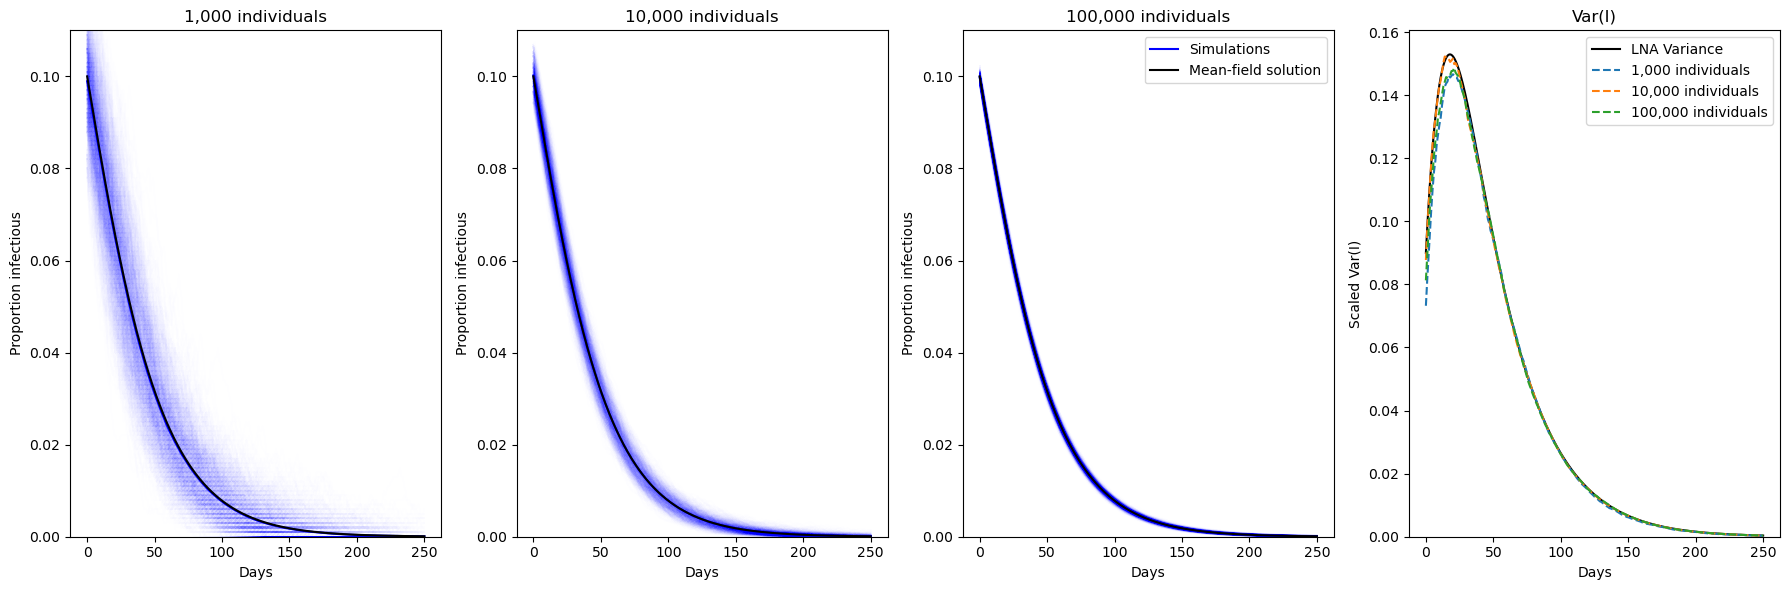

In [77]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_10000.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, df_1000_var*1000, linestyle = '--', label = '1,000 individuals')
axs[3].plot(days, df_10000_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_100000_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.11),(0,0.11),(0,0.11),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [78]:
file_list = glob.glob('Sim_results/lownorm/10000/low/I*.npy')
for i, file in enumerate(file_list):
    low_n = np.load(file) if i == 0 else np.vstack((low_n,np.load(file)))
low_n = low_n / 10000
df_1 = pd.DataFrame(low_n).T
stoch_cst = df_1.sub(df_1.mean(axis = 1), axis = 'rows')
df_1_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/lownorm/10000/med/I*.npy')
for i, file in enumerate(file_list):
    med_n = np.load(file) if i == 0 else np.vstack((med_n,np.load(file)))
med_n = med_n / 10000
df_2 = pd.DataFrame(med_n).T
stoch_cst = df_2.sub(df_2.mean(axis = 1), axis = 'rows')
df_2_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/lownorm/10000/high/I*.npy')
for i, file in enumerate(file_list):
    high_n = np.load(file) if i == 0 else np.vstack((high_n,np.load(file)))
high_n = high_n / 10000
df_3 = pd.DataFrame(high_n).T
stoch_cst = df_3.sub(df_3.mean(axis = 1), axis = 'rows')
df_3_var = stoch_cst.var(axis=1).values

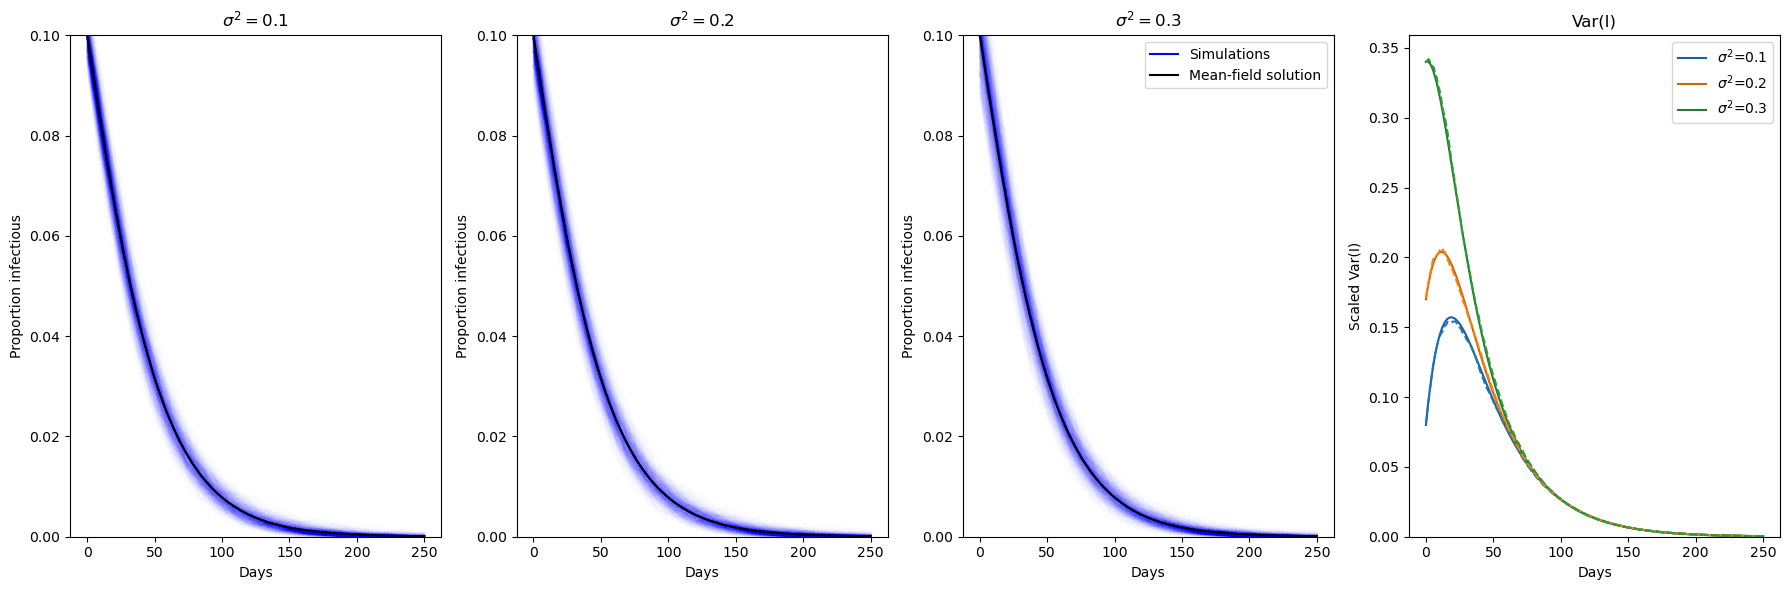

In [83]:
X0 = [0.9, 0.1, 0, 0.1, 0, 0.08]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
Sigmalow = sol[:,5]

X0 = [0.9, 0.1, 0, 0.1, 0, 0.17]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
Sigmamed = sol[:,5]

X0 = [0.9, 0.1, 0, 0.1, 0, 0.34]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
Sigmahigh = sol[:,5]

fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_2.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_2.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_3.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_3.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigmalow,  color='#1b5fa7', label = f'$\sigma^2$=0.1')
axs[3].plot(ts, Sigmamed,  color='#cc6600', label = f'$\sigma^2$=0.2')
axs[3].plot(ts, Sigmahigh, color='#237a3b', label = f'$\sigma^2$=0.3')
axs[3].plot(days, df_1_var*10000, linestyle = '--')
axs[3].plot(days, df_2_var*10000, linestyle = '--')
axs[3].plot(days, df_3_var*10000, linestyle = '--')
pop_size = [f'$\sigma^2=0.1$',f'$\sigma^2=0.2$',f'$\sigma^2=0.3$']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.1),(0,0.1),(0,0.1),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]}')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [84]:
# Change estimates slightly for SIR model
N = 1e5  # Total population
gamma = 1/14  # Recovery rate (1/gamma is the infectious period)
R_0 = 4 # Basic reproduction number estimated for alpha variant
mu = 0.00003424657  # Birth and death rate
beta0 = R_0 * (gamma+mu)
betat = lambda x: beta0
X0 = [0.4, 0.005, 1-0.4-0.005, 0, 0, 0]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
S, I, R = sol[:,0], sol[:,1], sol[:,2]
Sigma11, Sigma12, Sigma22 = sol[:,3], sol[:,4], sol[:,5]
days = np.arange(0,251)

In [85]:
file_list = glob.glob('Sim_results/high/1000/I*.npy')
for i, file in enumerate(file_list):
    high_1000 = np.load(file) if i == 0 else np.vstack((high_1000,np.load(file)))
high_1000 = high_1000 / 1000
df_1000 = pd.DataFrame(high_1000).T
stoch_cst = df_1000.sub(df_1000.mean(axis = 1), axis = 'rows')
df_1000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/high/10000/I*.npy')
for i, file in enumerate(file_list):
    high_10000 = np.load(file) if i == 0 else np.vstack((high_10000,np.load(file)))
high_10000 = high_10000 / 10000
df_10000 = pd.DataFrame(high_10000).T
stoch_cst = df_10000.sub(df_10000.mean(axis = 1), axis = 'rows')
df_10000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/high/100000/I*.npy')
for i, file in enumerate(file_list):
    high_100000 = np.load(file) if i == 0 else np.vstack((high_100000,np.load(file)))
high_100000 = high_100000 / 100000
df_100000 = pd.DataFrame(high_100000).T
stoch_cst = df_100000.sub(df_100000.mean(axis = 1), axis = 'rows')
df_100000_var = stoch_cst.var(axis=1).values

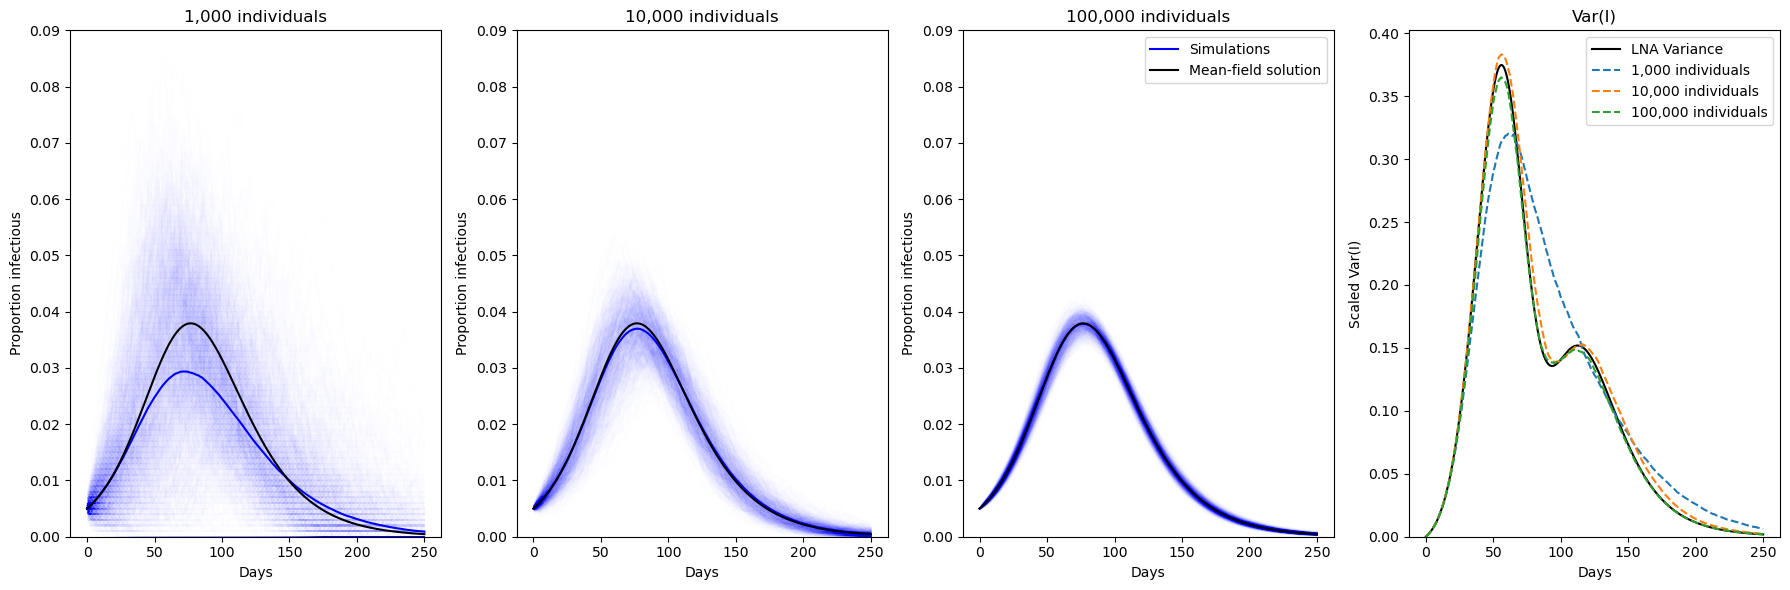

In [86]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_10000.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, df_1000_var*1000, linestyle = '--', label = '1,000 individuals')
axs[3].plot(days, df_10000_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_100000_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.09),(0,0.09),(0,0.09),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [87]:
np.sum(np.max(high_1000,axis=1) > 2*high_1000[0,0])

9013

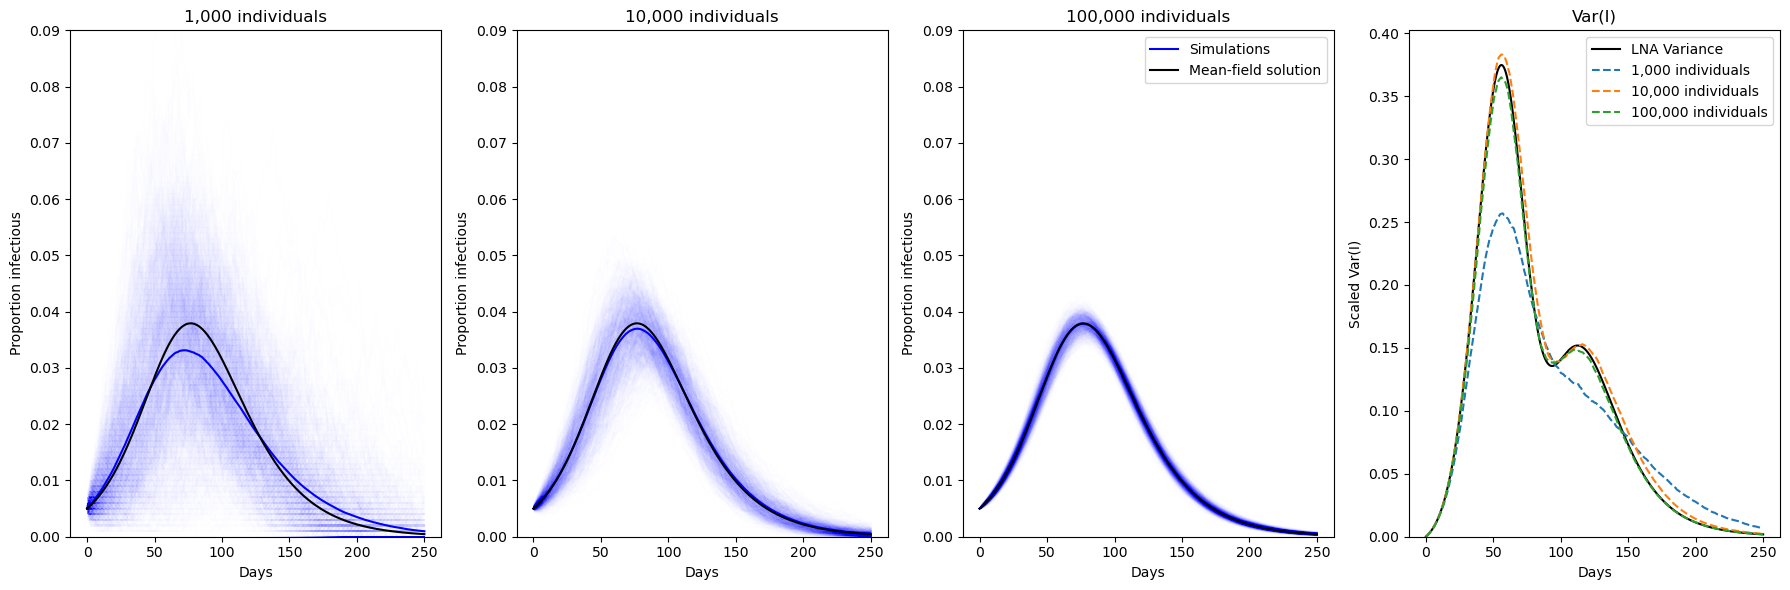

In [88]:
test_high_1000 = high_1000[np.where(np.max(high_1000,axis=1) > 0.02)]
test_df_1000 = pd.DataFrame(test_high_1000).T
test_stoch_cst = test_df_1000.sub(test_df_1000.mean(axis = 1), axis = 'rows')
test_df_1000_var = test_stoch_cst.var(axis=1).values
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, test_df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, test_df_1000.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_10000.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, test_df_1000_var*1000, linestyle = '--', label = '1,000 individuals')
axs[3].plot(days, df_10000_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_100000_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.09),(0,0.09),(0,0.09),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [89]:
np.shape(high_1000)

(10000, 251)

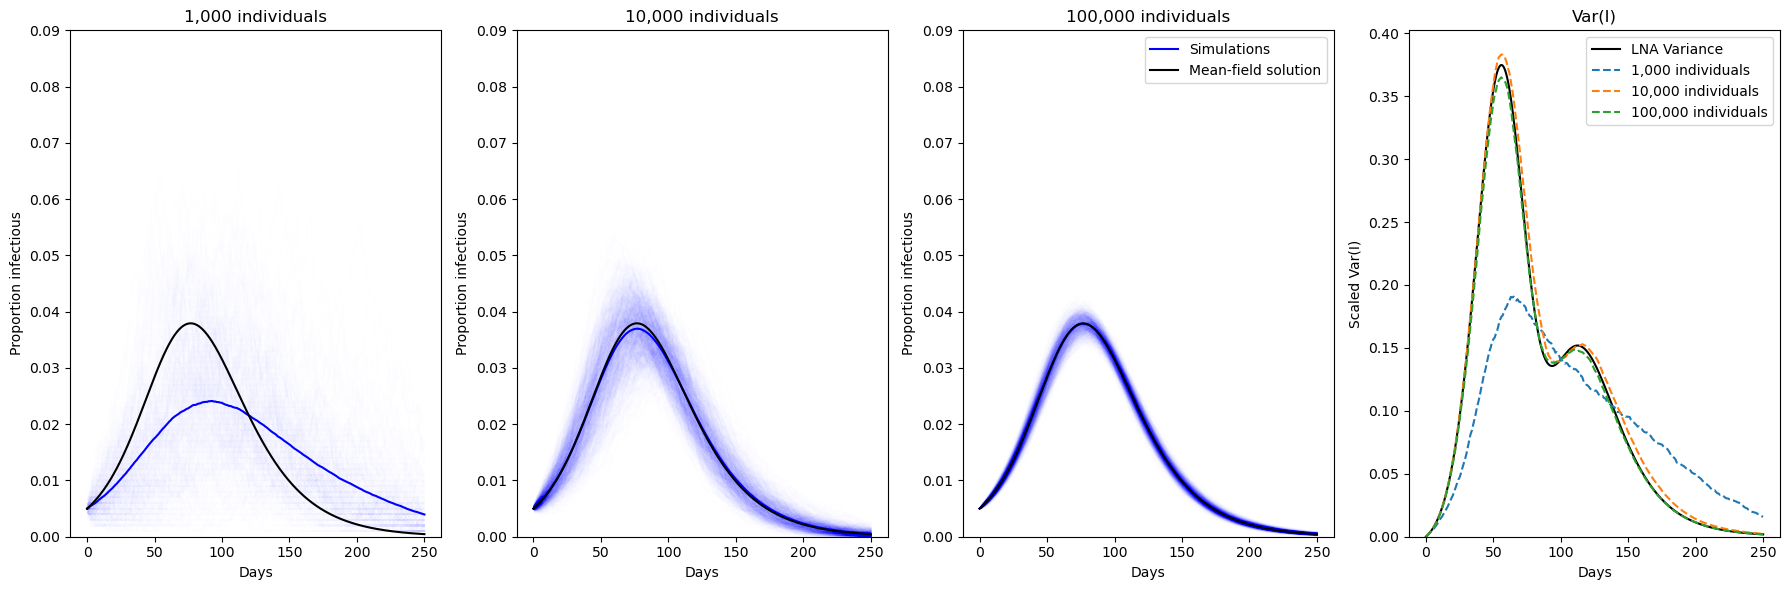

In [90]:
test_high_1000 = high_1000[np.where(high_1000[:,-1] != 0)]
test_df_1000 = pd.DataFrame(test_high_1000).T
test_stoch_cst = test_df_1000.sub(test_df_1000.mean(axis = 1), axis = 'rows')
test_df_1000_var = test_stoch_cst.var(axis=1).values
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, test_df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, test_df_1000.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_10000.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, test_df_1000_var*1000, linestyle = '--', label = '1,000 individuals')
axs[3].plot(days, df_10000_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_100000_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.09),(0,0.09),(0,0.09),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [91]:
ps = np.array([0.4, 0.005, 1-0.4-0.005])
init_var = np.diag(ps) - np.outer(ps,ps)
X0 = [0.4, 0.005, 1-0.4-0.005, init_var[0,0], init_var[0,1], init_var[0,2], init_var[1,1], init_var[1,2], init_var[2,2]]
sol = odeint(test_int_multin, X0, ts, args=(betat, gamma, mu))
S, I, R = sol[:,0], sol[:,1], sol[:,2]
Sigma22 = sol[:,6]

In [92]:
file_list = glob.glob('Sim_results/highrand/1000/I*.npy')
for i, file in enumerate(file_list):
    high_1000 = np.load(file) if i == 0 else np.vstack((high_1000,np.load(file)))
high_1000 = high_1000 / 1000
df_1000 = pd.DataFrame(high_1000).T
stoch_cst = df_1000.sub(df_1000.mean(axis = 1), axis = 'rows')
df_1000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/highrand/10000/I*.npy')
for i, file in enumerate(file_list):
    high_10000 = np.load(file) if i == 0 else np.vstack((high_10000,np.load(file)))
high_10000 = high_10000 / 10000
df_10000 = pd.DataFrame(high_10000).T
stoch_cst = df_10000.sub(df_10000.mean(axis = 1), axis = 'rows')
df_10000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/highrand/100000/I*.npy')
for i, file in enumerate(file_list):
    high_100000 = np.load(file) if i == 0 else np.vstack((high_100000,np.load(file)))
high_100000 = high_100000 / 100000
df_100000 = pd.DataFrame(high_100000).T
stoch_cst = df_100000.sub(df_100000.mean(axis = 1), axis = 'rows')
df_100000_var = stoch_cst.var(axis=1).values

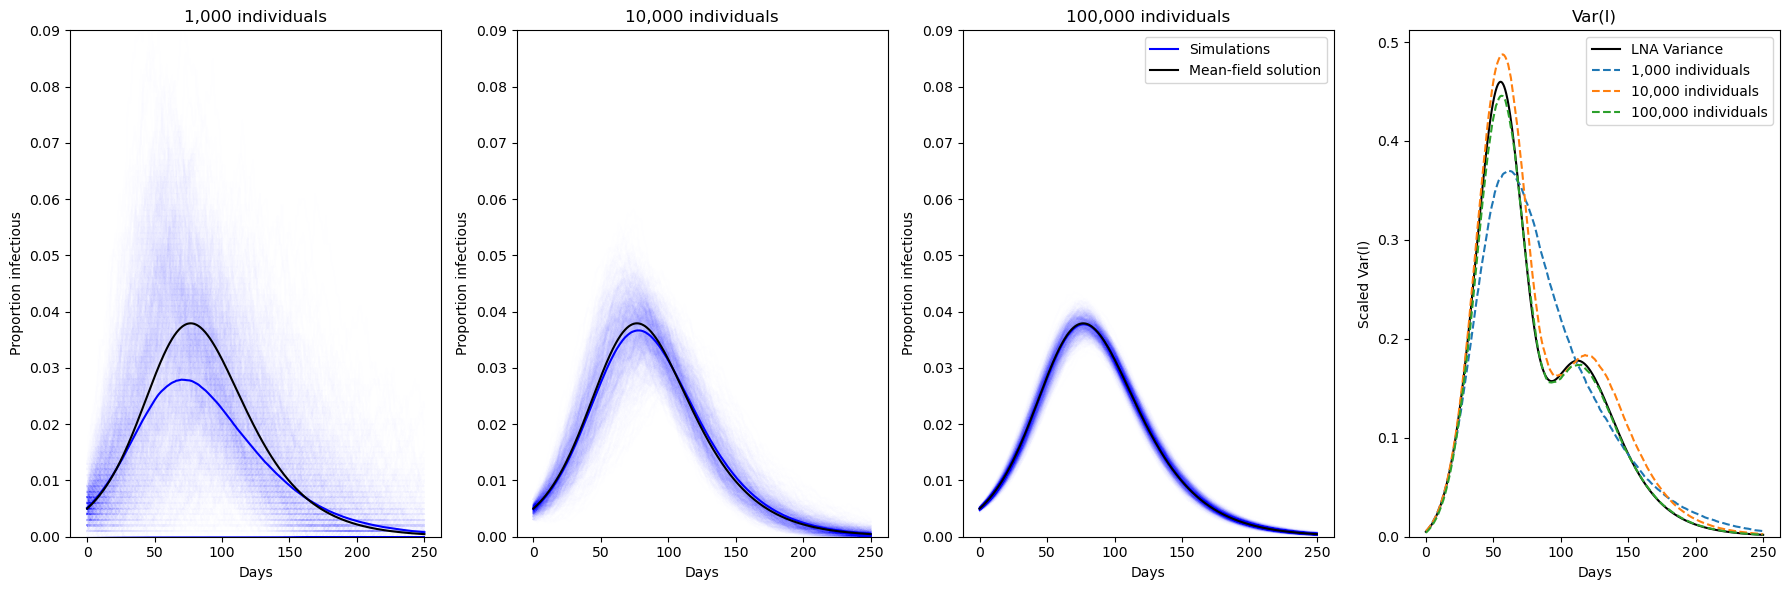

In [93]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_10000.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, df_1000_var*1000, linestyle = '--', label = '1,000 individuals')
axs[3].plot(days, df_10000_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_100000_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.09),(0,0.09),(0,0.09),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [94]:
file_list = glob.glob('Sim_results/highnorm/10000/low/I*.npy')
for i, file in enumerate(file_list):
    low_n = np.load(file) if i == 0 else np.vstack((low_n,np.load(file)))
low_n = low_n / 10000
df_1 = pd.DataFrame(low_n).T
stoch_cst = df_1.sub(df_1.mean(axis = 1), axis = 'rows')
df_1_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/highnorm/10000/med/I*.npy')
for i, file in enumerate(file_list):
    med_n = np.load(file) if i == 0 else np.vstack((med_n,np.load(file)))
med_n = med_n / 10000
df_2 = pd.DataFrame(med_n).T
stoch_cst = df_2.sub(df_2.mean(axis = 1), axis = 'rows')
df_2_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/highnorm/10000/high/I*.npy')
for i, file in enumerate(file_list):
    high_n = np.load(file) if i == 0 else np.vstack((high_n,np.load(file)))
high_n = high_n / 10000
df_3 = pd.DataFrame(high_n).T
stoch_cst = df_3.sub(df_3.mean(axis = 1), axis = 'rows')
df_3_var = stoch_cst.var(axis=1).values

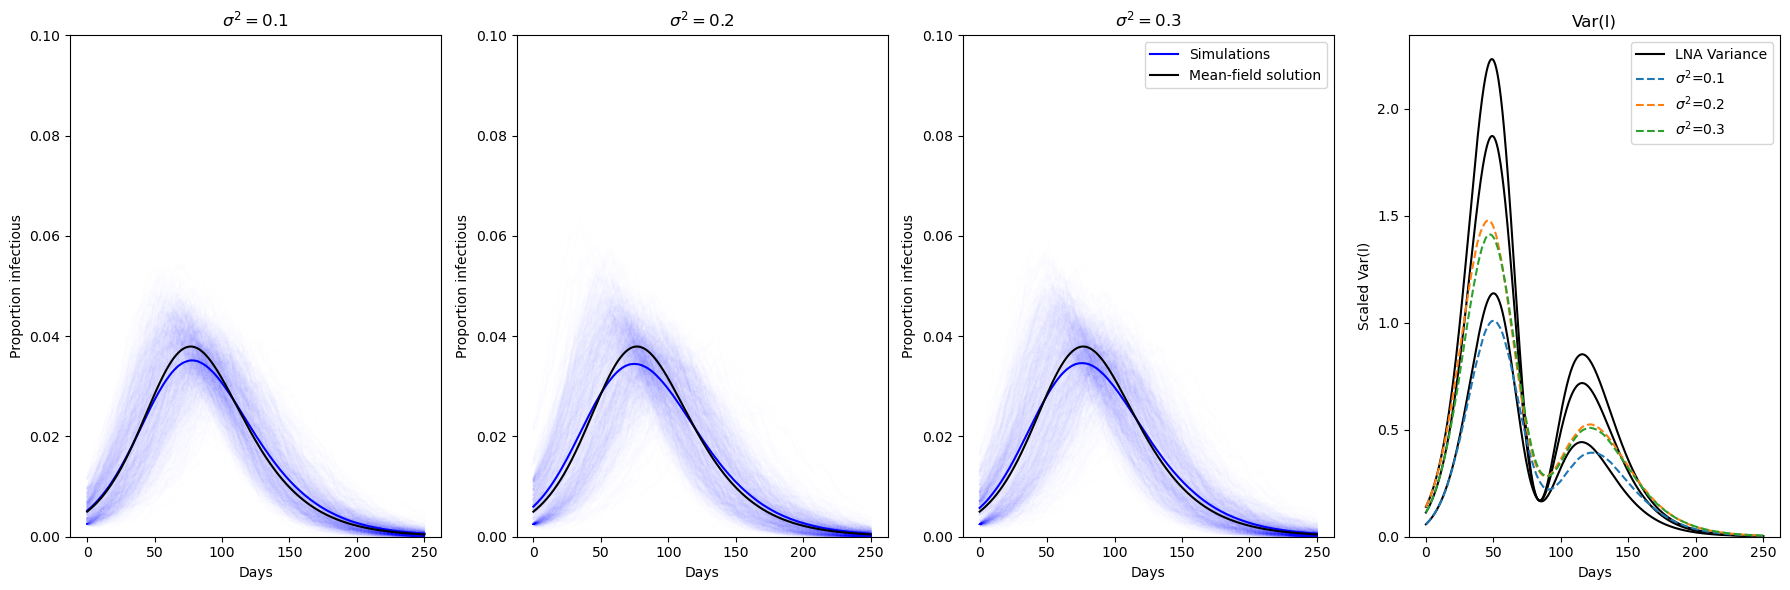

In [95]:
X0 = [0.4, 0.005, 1-0.4-0.005, 0.1, 0, 0.058]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
Sigmalow = sol[:,5]

X0 = [0.4, 0.005, 1-0.4-0.005, 0.1, 0, 0.1398]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
Sigmamed = sol[:,5]

X0 = [0.4, 0.005, 1-0.4-0.005, 0.1, 0, 0.113]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
Sigmahigh = sol[:,5]

fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_2.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_2.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_3.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_3.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigmalow, color = 'k')
axs[3].plot(ts, Sigmamed, color = 'k')
axs[3].plot(ts, Sigmahigh, color = 'k', label='LNA Variance')
axs[3].plot(days, df_1_var*10000, linestyle = '--', label = f'$\sigma^2$=0.1')
axs[3].plot(days, df_2_var*10000, linestyle = '--', label = f'$\sigma^2$=0.2')
axs[3].plot(days, df_3_var*10000, linestyle = '--', label = f'$\sigma^2$=0.3')
pop_size = [f'$\sigma^2=0.1$',f'$\sigma^2=0.2$',f'$\sigma^2=0.3$']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.1),(0,0.1),(0,0.1),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]}')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [96]:
file_list = glob.glob('Sim_results/hightnorm/10000/low/I*.npy')
for i, file in enumerate(file_list):
    low_n = np.load(file) if i == 0 else np.vstack((low_n,np.load(file)))
low_n = low_n / 10000
df_1 = pd.DataFrame(low_n).T
stoch_cst = df_1.sub(df_1.mean(axis = 1), axis = 'rows')
df_1_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/hightnorm/10000/med/I*.npy')
for i, file in enumerate(file_list):
    med_n = np.load(file) if i == 0 else np.vstack((med_n,np.load(file)))
med_n = med_n / 10000
df_2 = pd.DataFrame(med_n).T
stoch_cst = df_2.sub(df_2.mean(axis = 1), axis = 'rows')
df_2_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/hightnorm/10000/high/I*.npy')
for i, file in enumerate(file_list):
    high_n = np.load(file) if i == 0 else np.vstack((high_n,np.load(file)))
high_n = high_n / 10000
df_3 = pd.DataFrame(high_n).T
stoch_cst = df_3.sub(df_3.mean(axis = 1), axis = 'rows')
df_3_var = stoch_cst.var(axis=1).values

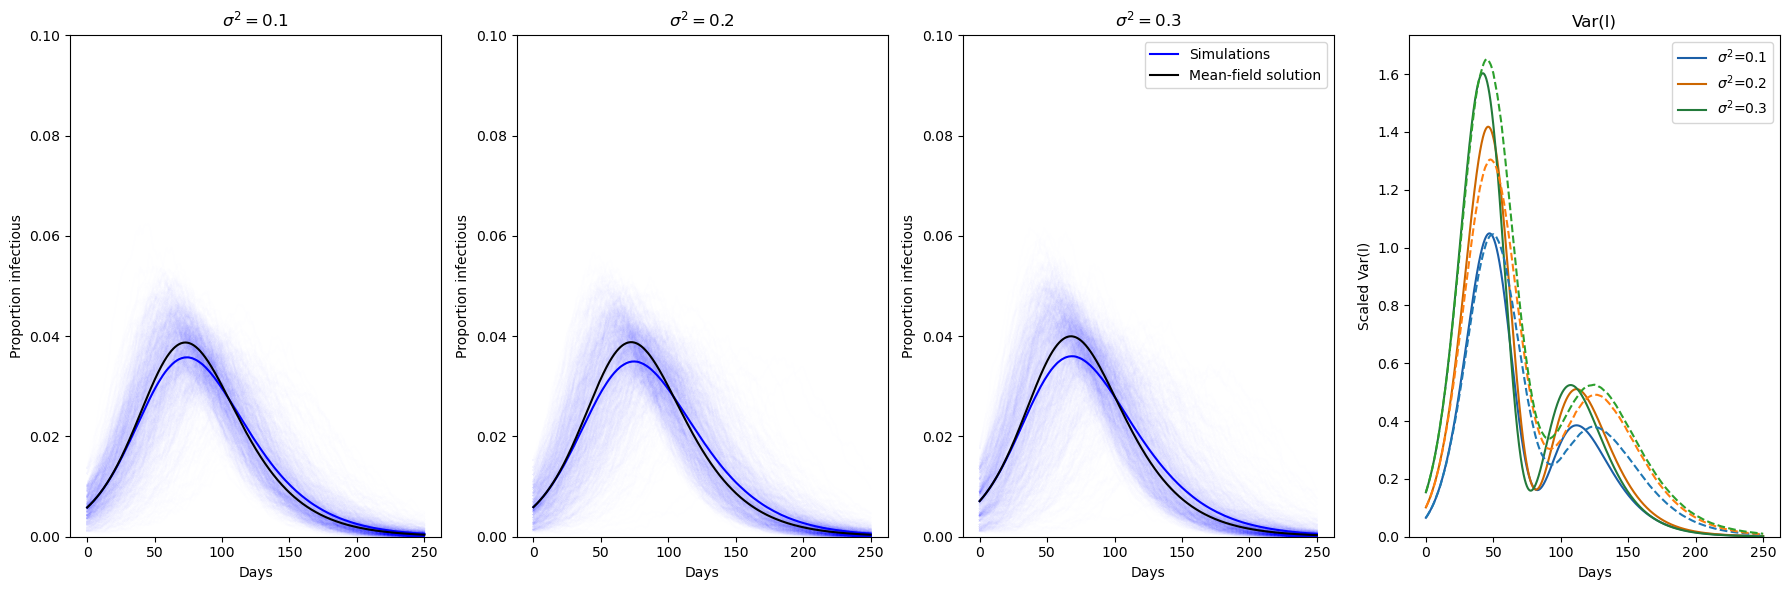

In [107]:
X0 = [0.4, df_1.mean(axis=1)[0], 1-0.4-0.005, 0.1, 0, 10000*df_1.var(axis=1)[0]]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
Sigmalow = sol[:,5]
Ilow = sol[:,1]

X0 = [0.4, df_2.mean(axis=1)[0], 1-0.4-0.005, 0.1, 0, 10000*df_2.var(axis=1)[0]]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
Sigmamed = sol[:,5]
Imed = sol[:,1]

X0 = [0.4, df_3.mean(axis=1)[0], 1-0.4-0.005, 0.1, 0, df_3.var(axis=1)[0]*10000]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
Sigmahigh = sol[:,5]
Ihigh = sol[:,1]

fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1.mean(axis = 1), color = 'b')
axs[0].plot(ts, Ilow, color = 'k')
axs[1].plot(days, df_2.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_2.mean(axis = 1), color = 'b')
axs[1].plot(ts, Imed, color = 'k')
axs[2].plot(days, df_3.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_3.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, Ihigh, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigmalow,  color='#1b5fa7', label = f'$\sigma^2$=0.1')
axs[3].plot(ts, Sigmamed,  color='#cc6600', label = f'$\sigma^2$=0.2')
axs[3].plot(ts, Sigmahigh, color='#237a3b', label = f'$\sigma^2$=0.3')
axs[3].plot(days, df_1_var*10000, linestyle = '--')
axs[3].plot(days, df_2_var*10000, linestyle = '--')
axs[3].plot(days, df_3_var*10000, linestyle = '--')
pop_size = [f'$\sigma^2=0.1$',f'$\sigma^2=0.2$',f'$\sigma^2=0.3$']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.1),(0,0.1),(0,0.1),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]}')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()